Titanic Project with Keras and Deep Learning

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
pd.set_option("display.max_columns",100)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Load the Dataset

In [46]:
df1=pd.read_csv("C:\\Users\\july.rabot\\Documents\\Mes_Projets\\WorkshopRER8\\data\\train.csv")
df2=pd.read_csv("C:\\Users\\july.rabot\\Documents\\Mes_Projets\\WorkshopRER8\\data\\test.csv")

In [47]:
df=pd.concat([df1,df2],ignore_index=True)

Exploratory Dataset

In [48]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 122.8 KB


In [50]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [51]:
df.shape

(1309, 12)

EDA

In [52]:
df.Name.value_counts()

Name
Connolly, Miss. Kate                                   2
Kelly, Mr. James                                       2
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
                                                      ..
Spector, Mr. Woolf                                     1
Oliva y Ocana, Dona. Fermina                           1
Saether, Mr. Simon Sivertsen                           1
Ware, Mr. Frederick                                    1
Peter, Master. Michael J                               1
Name: count, Length: 1307, dtype: int64

In [53]:
df["Title"]=df["Name"].str.extract("([A-Za-z]+)\.",expand=False)
df['Title']=df['Title'].replace(['Ms','Mlle'],'Miss')
df['Title']=df['Title'].replace(['Mme','Countess','Lady','Dona'],'Mrs')
df['Title']=df['Title'].replace(['Dr','Major','Col','Capt','Sir','Rev','Jonkheer','Don'],'Mr')

<Axes: xlabel='count', ylabel='Title'>

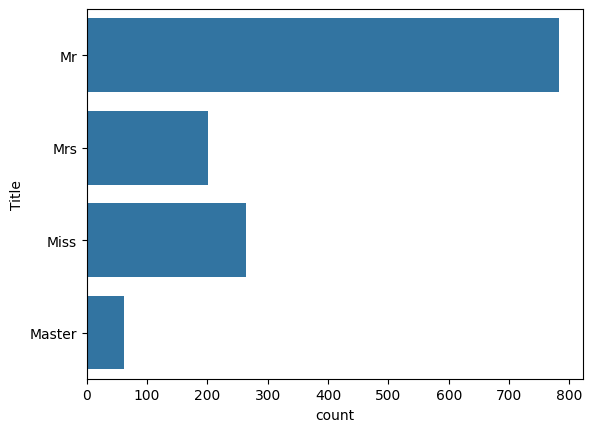

In [54]:
df['Title'].value_counts()
sns.countplot(df["Title"])

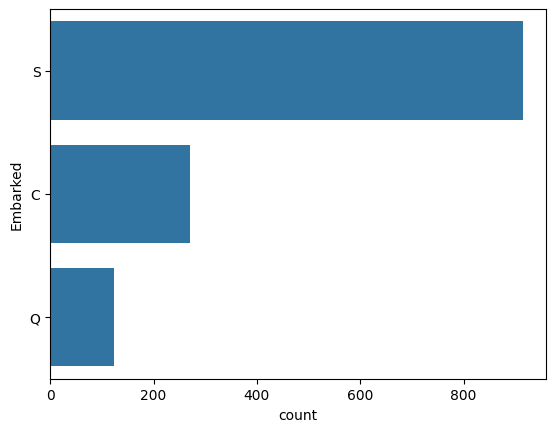

In [55]:
df["Age"].fillna(df.groupby("Title")["Age"].transform("median"),inplace=True)
del df["Cabin"]
df["Fare"].fillna(df["Fare"].median(),inplace=True)
df['Family']=df['SibSp']+df['Parch']+1
sns.countplot(df["Embarked"])
hue=df["Survived"]

In [56]:
df["Embarked"]=df["Embarked"].fillna("S")
df.drop(['Ticket'],axis=1,inplace=True)
df.drop("Name",axis=1,inplace=True)
df=pd.get_dummies(df,drop_first=True)
df.shape
x,y=df[:891].drop("Survived",axis=1),df[:891][["Survived"]]
x.shape,y.shape

((891, 13), (891, 1))

Prediction

In [57]:
def result_func(model,count):
    predict_x=model.predict(df[891:].drop("Survived",axis=1))
    result_dataset=pd.DataFrame()
    result_dataset["PassengerId"]=df[891:]["PassengerId"]
    result_dataset["Predict"]=predict_x
    result_dataset["Survived"]=result_dataset["Predict"].map(lambda s:1 if s>=0.5 else 0 )
    print(result_dataset["Survived"].value_counts().plot.bar())
    result_dataset.drop("Predict",axis=1).to_csv("titanic_deep_learning_result_model{}.csv".format(count),index=False)
    return result_dataset 

In [58]:
model=Sequential()
model.add(Dense(13,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(3,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [59]:
model.compile(loss='binary_crossentropy',optimizer="adam",metrics=["accuracy"])

In [60]:
model.fit(x,y,epochs=200,batch_size=10,verbose=1)

Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.6027 - loss: 0.7215
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - accuracy: 0.6162 - loss: 0.6855
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.6162 - loss: 0.6812
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.6162 - loss: 0.6781
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - accuracy: 0.6162 - loss: 0.6754
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.6162 - loss: 0.6732
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.6162 - loss: 0.6717
Epoch 8/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.6162 - loss: 0.6704
Epoch 9/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.6162 - loss: 0.6693
Epoch 10/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.6162 - loss: 0.6685
Epoch 11/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.6162 - loss: 0.6680
Epoch 12/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,181 (4.62 KB)

 Trainable params: 393 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 788 (3.08 KB)

In [62]:
scores=model.evaluate(x,y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6162 - loss: 0.6659  


In [63]:
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

compile_metrics: 61.62%


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Axes(0.125,0.11;0.775x0.77)


,PassengerId,Predict,Survived
891,892,0.382935,0
892,893,0.382935,0
893,894,0.382935,0
894,895,0.382935,0
895,896,0.382935,0
...,...,...,...
1304,1305,0.382935,0
1305,1306,0.382935,0
1306,1307,0.382935,0
1307,1308,0.382935,0


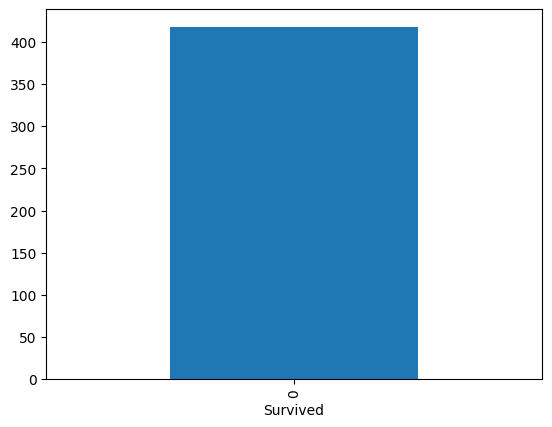

In [64]:
result_func(model,1)

In [65]:
history=model.fit(x,y,epochs=180,batch_size=10,verbose=1)

Epoch 1/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.6162 - loss: 0.6659
Epoch 2/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 3/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 4/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.6162 - loss: 0.6661
Epoch 5/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 6/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6162 - loss: 0.6660  
Epoch 7/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 8/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.6162 - loss: 0.6659
Epoch 9/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 10/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 11/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - accuracy: 0.6162 - loss: 0.6660
Epoch 12/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0

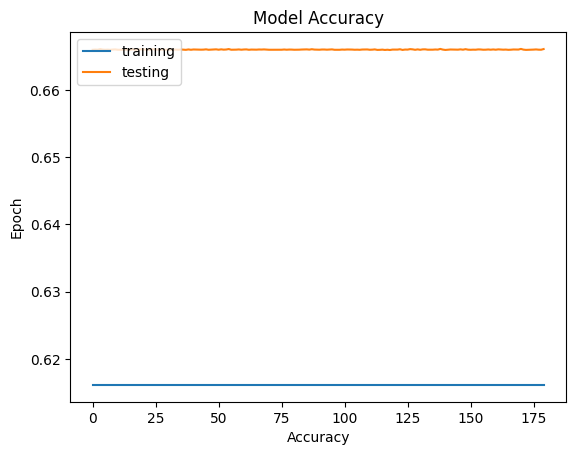

In [66]:
fig1=plt.figure(1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["loss"])
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

In [67]:
model=Sequential()
model.add(Dense(14,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [68]:
model.compile(loss='binary_crossentropy',optimizer="adam",metrics=["accuracy"])

In [69]:
model.fit(x,y,validation_split=0.2,epochs=150,batch_size=10,verbose=2)

Epoch 1/150
72/72 - 1s - 13ms/step - accuracy: 0.5871 - loss: 0.7419 - val_accuracy: 0.6425 - val_loss: 0.6882
Epoch 2/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6877 - val_accuracy: 0.6425 - val_loss: 0.6834
Epoch 3/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6843 - val_accuracy: 0.6425 - val_loss: 0.6793
Epoch 4/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6818 - val_accuracy: 0.6425 - val_loss: 0.6758
Epoch 5/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6796 - val_accuracy: 0.6425 - val_loss: 0.6730
Epoch 6/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6776 - val_accuracy: 0.6425 - val_loss: 0.6703
Epoch 7/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6760 - val_accuracy: 0.6425 - val_loss: 0.6682
Epoch 8/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6746 - val_accuracy: 0.6425 - val_loss: 0.6661
Epoch 9/150
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6736 - val_accuracy: 0.6425 - val_loss: 0.6641
Epoch 10/

In [70]:
scores=model.evaluate(x,y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6162 - loss: 0.6660 


In [71]:
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

compile_metrics: 61.62%


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Axes(0.125,0.11;0.775x0.77)


,PassengerId,Predict,Survived
891,892,0.390947,0
892,893,0.390947,0
893,894,0.390947,0
894,895,0.390947,0
895,896,0.390947,0
...,...,...,...
1304,1305,0.390947,0
1305,1306,0.390947,0
1306,1307,0.390947,0
1307,1308,0.390947,0


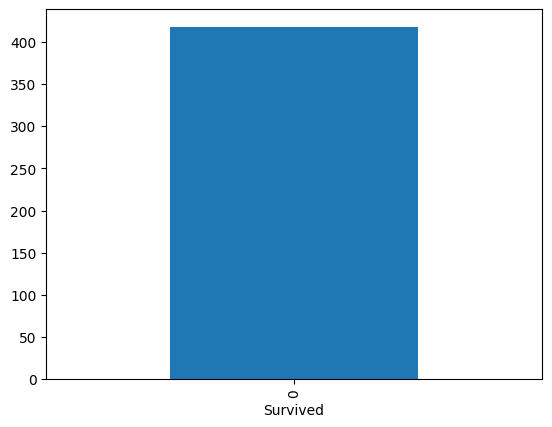

In [72]:
result_func(model,2)

In [73]:
history=model.fit(x,y,validation_split=0.2,epochs=200,batch_size=10,verbose=2)

Epoch 1/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 2/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 3/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 4/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6691 - val_accuracy: 0.6425 - val_loss: 0.6542
Epoch 5/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 6/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 7/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 8/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6690 - val_accuracy: 0.6425 - val_loss: 0.6545
Epoch 9/200
72/72 - 0s - 2ms/step - accuracy: 0.6096 - loss: 0.6691 - val_accuracy: 0.6425 - val_loss: 0.6544
Epoch 10/2

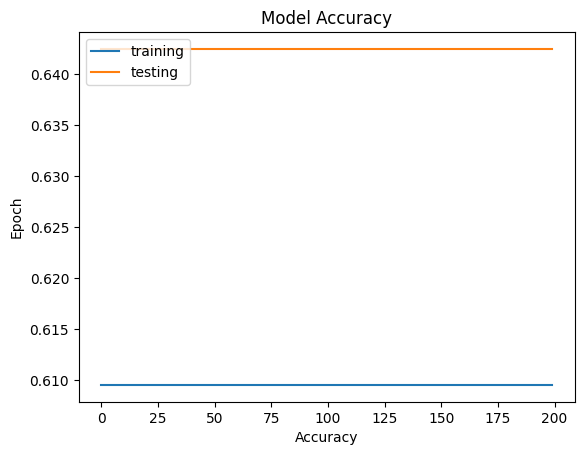

In [74]:
fig1=plt.figure(1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

<function matplotlib.pyplot.show(close=None, block=None)>

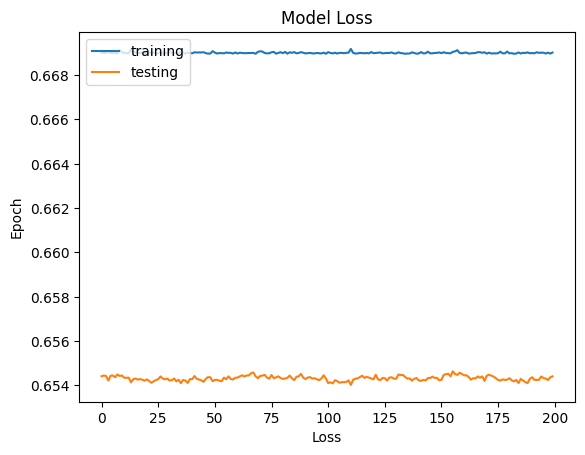

In [75]:
fig1=plt.figure(2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Loss")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

plt.show

Apprentissage profond de Keras sur les données du Titanic

In [76]:
# data processing
import numpy as np
import pandas as pd 

# machine learning
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# utils
import time
from datetime import timedelta

# some configuratin flags and variables
verbose=0 # Use in classifier

# Input files
file_train='C:\\Users\\july.rabot\\Documents\\Mes_Projets\\WorkshopRER8\\data\\train.csv'
file_test='C:\\Users\\july.rabot\\Documents\\Mes_Projets\\WorkshopRER8\\data\\test.csv'

# defeine random seed for reproducibility
seed = 69
np.random.seed(seed)

# read training data
train_df = pd.read_csv(file_train,index_col='PassengerId')

In [77]:
# Show the columns
train_df.columns.values

<StringArray>
['Survived',   'Pclass',     'Name',      'Sex',      'Age',    'SibSp',
    'Parch',   'Ticket',     'Fare',    'Cabin', 'Embarked']
Length: 11, dtype: str

In [78]:
# Show the shape
train_df.shape

(891, 11)

In [79]:
# preview the training dara
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
# Show that there is NaN data (Age,Fare Embarked), that needs to be handled during data cleansing
train_df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [81]:
def prep_data(df):
    # Drop unwanted features
    df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
    
    # Fill missing data: Age and Fare with the mean, Embarked with most frequent value
    df[['Age']] = df[['Age']].fillna(value=df[['Age']].mean())
    df[['Fare']] = df[['Fare']].fillna(value=df[['Fare']].mean())
    df[['Embarked']] = df[['Embarked']].fillna(value=df['Embarked'].value_counts().idxmax())
    
    # Convert categorical  features into numeric
    df['Sex'] = df['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
      
    # Convert Embarked to one-hot
    enbarked_one_hot = pd.get_dummies(df['Embarked'], prefix='Embarked')
    df = df.drop('Embarked', axis=1)
    df = df.join(enbarked_one_hot)

    return df

In [82]:
train_df = prep_data(train_df)
train_df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [83]:
# X contains all columns except 'Survived'  
X = train_df.drop(['Survived'], axis=1).values.astype(float)

# It is almost always a good idea to perform some scaling of input values when using neural network models (jb).

scale = StandardScaler()
X = scale.fit_transform(X)

# Y is just the 'Survived' column
Y = train_df['Survived'].values

In [84]:
def create_model(optimizer='adam', init='uniform'):
    # create model
    if verbose: print("**Create model with optimizer: %s; init: %s" % (optimizer, init) )
    model = Sequential()
    model.add(Dense(16, input_dim=X.shape[1], kernel_initializer=init, activation='relu'))
    model.add(Dense(8, kernel_initializer=init, activation='relu'))
    model.add(Dense(4, kernel_initializer=init, activation='relu'))
    model.add(Dense(1, kernel_initializer=init, activation='sigmoid'))
    # Compile model
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [85]:
run_gridsearch = False

if run_gridsearch:
    
    start_time = time.time()
    if verbose: print (time.strftime( "%H:%M:%S " + "GridSearch started ... " ) )
    optimizers = ['rmsprop', 'adam']
    inits = ['glorot_uniform', 'normal', 'uniform']
    epochs = [50, 100, 200, 400]
    batches = [5, 10, 20]
    
    model = KerasClassifier(build_fn=create_model, verbose=verbose)
    
    param_grid = dict(optimizer=optimizers, epochs=epochs, batch_size=batches, init=inits)
    grid = GridSearchCV(estimator=model, param_grid=param_grid)
    grid_result = grid.fit(X, Y)
    
    # summarize results
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    if verbose: 
        for mean, stdev, param in zip(means, stds, params):
            print("%f (%f) with: %r" % (mean, stdev, param))
        elapsed_time = time.time() - start_time  
        print ("Time elapsed: ",timedelta(seconds=elapsed_time))
        
    best_epochs = grid_result.best_params_['epochs']
    best_batch_size = grid_result.best_params_['batch_size']
    best_init = grid_result.best_params_['init']
    best_optimizer = grid_result.best_params_['optimizer']
    
else:
    # pre-selected paramters
    best_epochs = 200
    best_batch_size = 5
    best_init = 'glorot_uniform'
    best_optimizer = 'rmsprop'

In [86]:
# Create a classifier with best parameters
model_pred = KerasClassifier(build_fn=create_model, optimizer=best_optimizer, init=best_init, epochs=best_epochs, batch_size=best_batch_size, verbose=verbose)
model_pred.fit(X, Y)

# Read test data
test_df = pd.read_csv(file_test,index_col='PassengerId')
# Prep and clean data
test_df = prep_data(test_df)
# Create X_test
X_test = test_df.values.astype(float)
# Scaling
X_test = scale.transform(X_test)

# Predict 'Survived'
prediction = model_pred.predict(X_test)

Save predictions

In [88]:
survived_final = prediction.flatten()

submission = pd.DataFrame({
    'PassengerId': test_df.index,
    'Survived': survived_final
})

# Tri et export
submission.sort_values('PassengerId', inplace=True)    
submission.to_csv('submission-simple-cleansing.csv', index=False)

Part 2 - Predict the missing data in the Age feature

In [89]:
# Read the data
file_train='C:\\Users\\july.rabot\\Documents\\Mes_Projets\\WorkshopRER8\\data\\train.csv'
file_test='C:\\Users\\july.rabot\\Documents\\Mes_Projets\\WorkshopRER8\\data\\test.csv'
    
df_train = pd.read_csv(file_train,index_col='PassengerId')
df_test = pd.read_csv(file_test,index_col='PassengerId')  
l = len(df_train.index)
    

## All data train and test in one dataframe 
dfa = df_train.append(df_test)

# Drop unwanted features
dfa = dfa.drop(['Name', 'Ticket', 'Cabin'], axis=1)
    
# Fill missing data: Fare with mean, Embarked with most frequent value
dfa[['Fare']] = dfa[['Fare']].fillna(value=dfa[['Fare']].mean())
dfa[['Embarked']] = dfa[['Embarked']].fillna(value=dfa['Embarked'].value_counts().idxmax())
    
# Convert categorical features into numeric
dfa['Sex'] = dfa['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

# Convert 'Embarked' to one-hot
enbarked_one_hot = pd.get_dummies(dfa['Embarked'], prefix='Embarked')
dfa = dfa.drop('Embarked', axis=1)
dfa = dfa.join(enbarked_one_hot)

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
dfa.head()

Split data in to training set (Age not null) and 'to-be-predicted' set (Age in nan)

In [ ]:
# Split data in to training set (Age not null) and 'to-be-predicted' set (Age in nan)
df_age_train = dfa[dfa.Age.notnull()]
df_age_nan = dfa[dfa.Age.isnull()]

In [ ]:
# split data into input X and output Y
X = df_age_train.drop(['Age', 'Survived'], axis=1).values.astype(float)
Y = df_age_train['Age'].values.astype(float)

X_test = df_age_nan.drop(['Age', 'Survived'], axis=1).values.astype(float)

def age_model():
    # create model
    model = Sequential()
    model.add(Dense(32, input_dim=X.shape[1], kernel_initializer='normal', activation='relu'))
    model.add(Dense(16, kernel_initializer='normal', activation='relu'))
    model.add(Dense(8, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

Create a pipeline

In [ ]:
estimators = []
estimators.append(('standardize', StandardScaler()))
estimators.append(('mlp', KerasRegressor(build_fn=age_model, epochs=100, batch_size=5, verbose=verbose)))
pipeline = Pipeline(estimators)

Cross-validation

In [ ]:
kfold = KFold(n_splits=2, random_state=seed)
results = cross_val_score(pipeline, X, Y, cv=kfold)
print("Result: %.2f (%.2f) MSE" % (results.mean(), results.std()))

Predict

In [ ]:
pipeline.fit(X, Y)
prediction_train = pipeline.predict(X)
prediction_test = pipeline.predict(X_test)

Generate new input files for the training and test data with predicted age

In [ ]:
# Create a data frame with PassengerId and predicted age
df_age_pred = pd.DataFrame({
    'PassengerId': df_age_nan.index,
    'Age_pred': prediction_test.astype(int)
})
df_age_pred.set_index('PassengerId', inplace=True)
   

# Add column with predicted age to the dataframe with all data (dfa)
dfa2 = df_train.append(df_test) 
dfa_pred = pd.concat([dfa2, df_age_pred], axis=1)   

# Update Age column with prediction where nan and remove Age_pred
dfa_pred['Age'] = np.where(pd.isnull(dfa_pred['Age']), dfa_pred['Age_pred'] , dfa_pred['Age'])
dfa_pred = dfa_pred.drop(['Age_pred'], axis=1)

# Create new files
l = len(df_train)
df_train2 = dfa_pred[0:l] 
df_test2 = dfa_pred[l:] 
df_test2 = df_test2.drop(['Survived'], axis=1)

df_train2.to_csv('train-age-predicted.csv')
df_test2.to_csv('test-age-predicted.csv')

Part 3 - Wrangle, prepare, cleanse the titanic data manually

In [ ]:
train_df = pd.read_csv('../input/train.csv')
test_df = pd.read_csv('../input/test.csv')
train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)
combine = [train_df, test_df]

New title featue

In [ ]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    
train_df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

In [ ]:
# convert the categorical titles to ordinal.
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

# Drop Name feature
train_df = train_df.drop(['Name'], axis=1)
test_df = test_df.drop(['Name'], axis=1)
combine = [train_df, test_df]

Converting a categorical feature

In [ ]:
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

In [ ]:
train_df.head(10)

In [ ]:
guess_ages = np.zeros((2,3))
for dataset in combine:
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset['Sex'] == i) & \
                                  (dataset['Pclass'] == j+1)]['Age'].dropna()

            age_guess = guess_df.median()

            # Convert random age float to nearest .5 age
            guess_ages[i,j] = int( age_guess/0.5 + 0.5 ) * 0.5
            
    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[ (dataset.Age.isnull()) & (dataset.Sex == i) & (dataset.Pclass == j+1),\
                    'Age'] = guess_ages[i,j]

    dataset['Age'] = dataset['Age'].astype(int)

Create age bands and save ordinals based on these bands

In [ ]:
for dataset in combine:    
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age']

train_df.head()

Create new feature for FamilySize which combines Parch and SibSp

In [ ]:
combine = [train_df, test_df]
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

train_df[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=False).mean().sort_values(by='Survived', ascending=False)

Create another feature called IsAlone

In [ ]:
for dataset in combine:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1

train_df[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

Drop Parch, SibSp, and FamilySize features in favor of IsAlone

In [ ]:
train_df = train_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
test_df = test_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
combine = [train_df, test_df]

Create an artificial feature combining Pclass and Age

In [ ]:
for dataset in combine:
    dataset['Age*Class'] = dataset.Age * dataset.Pclass

train_df.loc[:, ['Age*Class', 'Age', 'Pclass']].head(10)

Completing a categorical feature

In [ ]:
freq_port = train_df.Embarked.dropna().mode()[0]

for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port)
    
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)

Fare feature to ordinal values based on the FareBand

In [ ]:
for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype(int)

combine = [train_df, test_df]

Save wrangled training and test data to files

In [ ]:
train_df.to_csv('train-wrangled.csv',index=False)
test_df.to_csv('test-wrangled.csv',index=False)

Part 4 - Predict 'Survived' with Kears based on wrangled input data

In [ ]:
# Input files
file_train='train-wrangled.csv'
file_test='test-wrangled.csv'

# read training data
train_df = pd.read_csv(file_train,index_col='PassengerId')

In [ ]:
# Show the columns
train_df.columns.values

In [ ]:
# Show the shape
train_df.shape

In [ ]:
# preview the training dara
train_df.head()

In [ ]:
# Show that there isn't any NaN data 
train_df.isnull().sum()

In [ ]:
# X contains all columns except 'Survived'  
X = train_df.drop(['Survived'], axis=1).values.astype(float)

# It is almost always a good idea to perform some scaling of input values when using neural network models (jb).

scale = StandardScaler()
X = scale.fit_transform(X)

# Y is just the 'Survived' column
Y = train_df['Survived'].values

Run GridSearch, optionally

In [ ]:
run_gridsearch = False

if run_gridsearch:
    
    start_time = time.time()
    if verbose: print (time.strftime( "%H:%M:%S " + "GridSearch started ... " ) )
    optimizers = ['rmsprop', 'adam']
    inits = ['glorot_uniform', 'normal', 'uniform']
    epochs = [50, 100, 200, 400]
    batches = [5, 10, 20]
    
    model = KerasClassifier(build_fn=create_model, verbose=verbose)
    
    param_grid = dict(optimizer=optimizers, epochs=epochs, batch_size=batches, init=inits)
    grid = GridSearchCV(estimator=model, param_grid=param_grid)
    grid_result = grid.fit(X, Y)
    
    # summarize results
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    if verbose: 
        for mean, stdev, param in zip(means, stds, params):
            print("%f (%f) with: %r" % (mean, stdev, param))
        elapsed_time = time.time() - start_time  
        print ("Time elapsed: ",timedelta(seconds=elapsed_time))
        
    best_epochs = grid_result.best_params_['epochs']
    best_batch_size = grid_result.best_params_['batch_size']
    best_init = grid_result.best_params_['init']
    best_optimizer = grid_result.best_params_['optimizer']
    
else:
    # pre-selected paramters
    best_epochs = 200
    best_batch_size = 5
    best_init = 'glorot_uniform'
    best_optimizer = 'rmsprop'

Build model and predit¶
Create a classifier with best parameters
Fit model
Predict 'Survived'

In [ ]:
# Create a classifier with best parameters
model_pred = KerasClassifier(build_fn=create_model, optimizer=best_optimizer, init=best_init, epochs=best_epochs, batch_size=best_batch_size, verbose=verbose)
model_pred.fit(X, Y)

# Read test data
test_df = pd.read_csv(file_test,index_col='PassengerId')

# Create X_test
X_test = test_df.values.astype(float)
# Scaling
X_test = scale.transform(X_test)

# Predict 'Survived'
prediction = model_pred.predict(X_test)

Save predictions

In [ ]:
submission = pd.DataFrame({
    'PassengerId': test_df.index,
    'Survived': prediction[:,0],
})

submission.sort_values('PassengerId', inplace=True)    
submission.to_csv('submission-manual-cleansing.csv', index=False)